# CTM-Based Song Recommendation System (GPU-Optimized)

This notebook implements a GPU-accelerated music recommendation pipeline using Contextualized Topic Models (CTM). It covers:

1. **GPU Setup & Detection** - Automatically detect and configure GPU usage
2. **Data Preprocessing** - Cleaning and tokenizing song lyrics for CTM input
3. **GPU-Accelerated CTM Training** - Training CombinedTM with CUDA acceleration
4. **GPU-Accelerated Embedding Generation** - Using GPU for sentence transformers
5. **Topic Labeling** - Generating interpretable topic names with LangChain + OpenAI
6. **Evaluation** - Computing topic coherence and diversity metrics
7. **Similarity Calculation** - Building song/artist vectors with GPU acceleration
8. **Diversity-Aware Recommendations** - Applying Maximal Marginal Relevance (MMR)

## 🚀 GPU Optimizations:
- **Automatic GPU detection** and fallback to CPU
- **CUDA-accelerated** SentenceTransformer embeddings
- **GPU-optimized** CTM training
- **Batch processing** for large datasets
- **Memory management** to avoid GPU OOM errors


In [1]:
# ===== GPU SETUP AND DETECTION =====
from dotenv import load_dotenv
from langchain.prompts import PromptTemplate
from langchain.schema import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from scipy.spatial.distance import cosine
import re
from nltk.tokenize import RegexpTokenizer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import nltk
from sentence_transformers import SentenceTransformer
from contextualized_topic_models.utils.preprocessing import WhiteSpacePreprocessing
from contextualized_topic_models.utils.data_preparation import TopicModelDataPreparation
from contextualized_topic_models.models.ctm import CombinedTM
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from datetime import datetime
from contextualized_topic_models.utils.preprocessing import (
    WhiteSpacePreprocessingStopwords,
)
from nltk.corpus import stopwords as stop_words
import os
import torch
import gc
from contextualized_topic_models.evaluation.measures import (
    CoherenceNPMI,
    TopicDiversity,
    CoherenceCV,
)
import pyLDAvis as vis
from difflib import SequenceMatcher
import lyricsgenius
import warnings
warnings.filterwarnings("ignore")



def setup_gpu_environment():
    """Setup GPU environment with proper memory management"""
    # Check CUDA availability

    cuda_available = torch.cuda.is_available()
    device_count = torch.cuda.device_count()
    print("🖥️  GPU Environment Setup:")
    print(f"   CUDA Available: {cuda_available}")

    if cuda_available:
        print(f"   GPU Device Count: {device_count}")
        for i in range(device_count):
            gpu_name = torch.cuda.get_device_name(i)
            gpu_memory = torch.cuda.get_device_properties(i).total_memory / 1024**3
            print(f"   GPU {i}: {gpu_name} ({gpu_memory:.1f} GB)")

        # Set memory management

        torch.cuda.empty_cache()

        # Set memory fraction to avoid OOM

        torch.cuda.set_per_process_memory_fraction(0.8)
        device = torch.device("cuda")
        print(f"   ✅ Using GPU: {torch.cuda.get_device_name(0)}")

    else:
        device = torch.device("cpu")
        print("   ⚠️  CUDA not available. Using CPU.")
        print(
            "   💡 To enable GPU: pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118"
        )

    # Set environment variables for optimal performance
    os.environ["TOKENIZERS_PARALLELISM"] = "false"  # Avoid warnings
    return device, cuda_available

def clear_gpu_memory():
    """Clear GPU memory cache"""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()
        print("🧹 GPU memory cleared")



def get_gpu_memory_usage():
    """Get current GPU memory usage"""
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        cached = torch.cuda.memory_reserved() / 1024**3
        return f"GPU Memory - Allocated: {allocated:.2f} GB, Cached: {cached:.2f} GB"
    return "GPU not available"



# Initialize GPU environment
device, cuda_available = setup_gpu_environment()
print(f"\n🎯 Device selected: {device}")

🖥️  GPU Environment Setup:
   CUDA Available: True
   GPU Device Count: 1
   GPU 0: NVIDIA GeForce RTX 3050 Laptop GPU (4.0 GB)
   ✅ Using GPU: NVIDIA GeForce RTX 3050 Laptop GPU

🎯 Device selected: cuda


In [2]:

# NLTK downloads
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

print("📦 All libraries imported successfully!")

# Load OpenAI API key
load_dotenv(override=True)
openai_api_key = os.getenv("OPENAI_API_KEY")
if not openai_api_key:
    print("⚠️ OpenAI API key not found. LLM-based labeling will be disabled.")

print(f"\n{get_gpu_memory_usage()}")

📦 All libraries imported successfully!

GPU Memory - Allocated: 0.00 GB, Cached: 0.00 GB


In [3]:
# ===== DATA LOADING =====

# Load your song lyrics dataset
data_path = "../Lyrics_extraction/scraped_lyrics_no_metadata.csv"
df = pd.read_csv(data_path)

def clean_lyrics_for_ctm(text):
    # Remove structural markers like [Chorus], [Verse], etc.
    text = re.sub(r'\[.*?\]', '', text)
    
    # Clean up whitespace and newlines
    text = re.sub(r'\n+', ' ', text)  # Replace newlines with spaces
    text = re.sub(r'\s+', ' ', text)  # Normalize whitespace    
    
    return text.strip()

df['lyrics'] = df['lyrics'].apply(clean_lyrics_for_ctm)

print(f"📊 Dataset Overview:")
print(f"   Songs: {len(df):,}")
print(f"   Artists: {df['artist'].nunique():,}")
print(f"   Columns: {list(df.columns)}")

# Display sample data
print("\n🎵 Sample songs:")
df.head(3)

📊 Dataset Overview:
   Songs: 3,000
   Artists: 300
   Columns: ['artist', 'song_title', 'lyrics']

🎵 Sample songs:


,artist,song_title,lyrics
0,21 Savage,Bank Account,"Ooh, ooh, oh, oh, oh, ow, ow Wow, wow, wow, ah..."
1,21 Savage,Ghostface Killers,"Metro Boomin want some more, nigga (Hey) Autom..."
2,21 Savage,Glock in My Lap,"Y'all niggas stop playin', nigga Y'all niggas ..."


In [4]:
# ===== GPU-OPTIMIZED PREPROCESSING =====


nltk.download("stopwords")
stopwords = list(stop_words.words("english"))
documents = df['lyrics'].tolist()


sp = WhiteSpacePreprocessingStopwords(documents, stopwords_list=stopwords, vocabulary_size=7000)
preprocessed_documents, unpreprocessed_corpus, vocab, retained_indices = sp.preprocess()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
clear_gpu_memory()
# Create TopicModelDataPreparation object
print("🔧 Preparing CTM training data...")

sentence_transformers_model = "all-mpnet-base-v2"
# tp = TopicModelDataPreparation("all-mpnet-base-v2")
print(f"   Using Sentence Transformers model: {sentence_transformers_model}")
tp = TopicModelDataPreparation(sentence_transformers_model) 
training_dataset = tp.fit(
    text_for_contextual=unpreprocessed_corpus,
    text_for_bow=preprocessed_documents, 
)

print(f"✅ CTM data prepared!")
print(f"   BoW vocabulary size: {len(tp.vocab):,}")
# print(f"   Contextual embedding size: {training_embeddings.shape[1]}")
print(f"\n{get_gpu_memory_usage()}")

🧹 GPU memory cleared
🔧 Preparing CTM training data...
   Using Sentence Transformers model: all-mpnet-base-v2


Batches:   0%|          | 0/15 [00:00<?, ?it/s]

✅ CTM data prepared!
   BoW vocabulary size: 6,959

GPU Memory - Allocated: 0.42 GB, Cached: 1.94 GB


In [6]:
# ===== GPU-ACCELERATED CTM TRAINING =====
warnings.filterwarnings('ignore')

def train_ctm_with_gpu(training_dataset, tp, n_topics=10, num_epochs=20, 
                      learning_rate=0.002, batch_size=200, n_samples=2000):
    """Train CTM model with GPU acceleration"""

    print(f"🚀 Training CombinedTM with {n_topics} topics...")
    print(f"   Epochs: {num_epochs}")
    print(f"   Learning rate: {learning_rate}")
    print(f"   Batch size: {batch_size}")
    print(f"   Samples: {n_samples}")
    contextual_size = len(training_dataset.X_contextual[0])
    # Initialize CTM model
    ctm = CombinedTM(
        bow_size=len(tp.vocab),
        contextual_size=contextual_size,
        learn_priors=True,
        n_components=n_topics,
        num_epochs=num_epochs,
        batch_size=batch_size,
        num_data_loader_workers=0 if cuda_available else 2,  # Avoid multiprocessing issues on GPU
        reduce_on_plateau=True,  # Enable learning rate reduction
    )

    # Set device for CTM training
    if cuda_available:
        print(f"   ✅ Training on GPU: {torch.cuda.get_device_name(0)}")
    else:
        print(f"   ⚠️  Training on CPU")

    # Clear memory before training
    clear_gpu_memory()

    # Train the model
    print("⏳ Training in progress...")
    start_time = datetime.now()

    try:
        ctm.fit(training_dataset)

        end_time = datetime.now()
        training_time = (end_time - start_time).total_seconds()

        print(f"✅ CTM training completed in {training_time:.1f} seconds!")
        print(f"   Average time per epoch: {training_time/num_epochs:.1f} seconds")

    except Exception as e:
        print(f"❌ Training failed: {str(e)}")
        clear_gpu_memory()
        raise

    return ctm

# Optimize parameters based on available hardware
if cuda_available:
    gpu_memory_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    
    if gpu_memory_gb < 6:  # Less than 6GB VRAM
        n_topics = 10
        batch_size = 100
        n_samples = 1000
    elif gpu_memory_gb < 12:  # Less than 12GB VRAM
        n_topics = 10
        batch_size = 200
        n_samples = 2000
    else:  # 12GB+ VRAM
        n_topics = 15
        batch_size = 300
        n_samples = 3000
else:
    n_topics = 10
    batch_size = 100
    n_samples = 1000

print(f"\n{get_gpu_memory_usage()}")
print(f"🎯 Optimized parameters: {n_topics} topics, batch size {batch_size}, {n_samples} samples")

# Train the CTM model
ctm = train_ctm_with_gpu(
    training_dataset, 
    tp, 
    n_topics=n_topics,
    num_epochs=10,
    batch_size=batch_size,
    n_samples=n_samples
)

print(f"\n{get_gpu_memory_usage()}")


GPU Memory - Allocated: 0.42 GB, Cached: 1.94 GB
🎯 Optimized parameters: 10 topics, batch size 100, 1000 samples
🚀 Training CombinedTM with 10 topics...
   Epochs: 10
   Learning rate: 0.002
   Batch size: 100
   Samples: 1000
   ✅ Training on GPU: NVIDIA GeForce RTX 3050 Laptop GPU
🧹 GPU memory cleared
⏳ Training in progress...


Epoch: [10/10]	 Seen Samples: [30000/30000]	Train Loss: 1474.1769322916666	Time: 0:00:00.650981: : 10it [00:06,  1.48it/s]
Sampling: [20/20]: : 20it [00:11,  1.81it/s]

✅ CTM training completed in 17.8 seconds!
   Average time per epoch: 1.8 seconds

GPU Memory - Allocated: 0.09 GB, Cached: 0.54 GB


📊 Analyzing discovered topics...
⟶ CV coherence (avg): 0.5327
⟶ CV coherence (per topic): [0.606321650636752, 0.5125515684322828, 0.5220334951609411, 0.42179150519832403, 0.6072628594951427, 0.5457805597486753, 0.3956054150441156, 0.568444357257077, 0.5527954543649933, 0.5944321513506192]
⟶ Topic Diversity: 0.7200


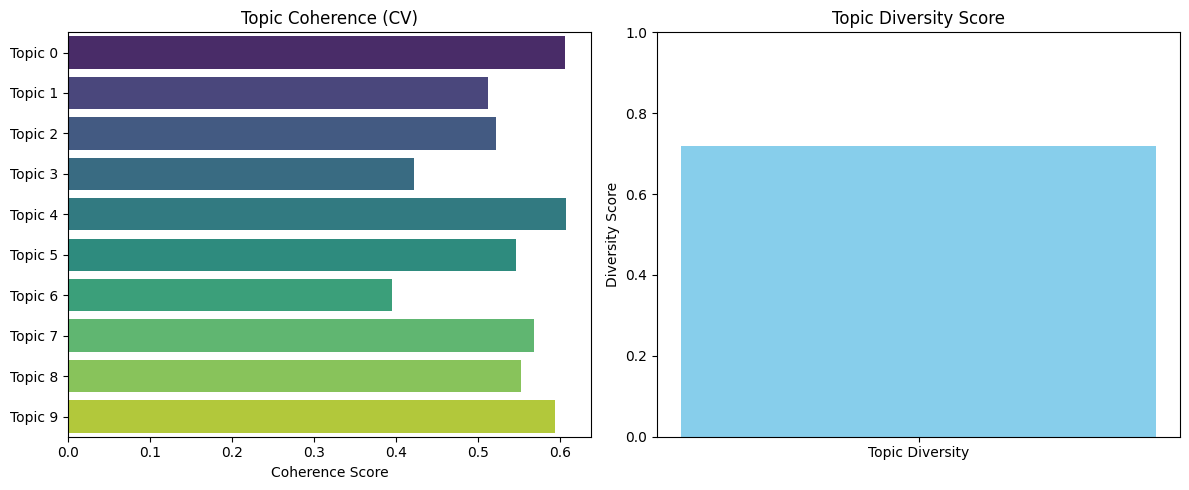

🧹 GPU memory cleared

GPU Memory - Allocated: 0.09 GB, Cached: 0.22 GB


In [7]:

# ===== TOPIC ANALYSIS AND EVALUATION =====

print("📊 Analyzing discovered topics...")

# Get topic-word distributions
topics = ctm.get_topic_lists(10)

# 2. load your pre‐processed “bag-of-words” texts
#    this must be a List[List[str]] — exactly what you passed as `text_for_bow` to TopicModelDataPreparation
texts = [
    doc.split()  # if you saved each preprocessed doc as a space‐joined string
    for doc in preprocessed_documents
] #List of list of str

# 3. import the CTM evaluation classes

# 4. compute NPMI coherence (a popular, normalized PMI metric)
npmi = CoherenceNPMI(topics=topics, texts=texts)
cv = CoherenceCV(topics=topics, texts= texts)
coherence_score = cv.score(topk=10)                   # average over topics
coherence_per_topic = cv.score(topk=10, per_topic=True)  # list of per‐topic scores

print(f"⟶ CV coherence (avg): {coherence_score:.4f}")
print(f"⟶ CV coherence (per topic): {coherence_per_topic}")

# 5. compute topic diversity (proportion of unique top‐words across topics)
diversity = TopicDiversity(topics=topics)
diversity_score = diversity.score(topk=10)

print(f"⟶ Topic Diversity: {diversity_score:.4f}")

# Plotting coherence
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
labels = [f"Topic {i}" for i in range(len(topics))]
sns.barplot(x=coherence_per_topic, y=labels, orient='h', palette='viridis')
plt.title('Topic Coherence (CV)')
plt.xlabel('Coherence Score')

plt.subplot(1, 2, 2)
plt.bar(['Topic Diversity'], [diversity_score], color='skyblue')
plt.title('Topic Diversity Score')
plt.ylabel('Diversity Score')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

# Memory cleanup
clear_gpu_memory()
print(f"\n{get_gpu_memory_usage()}")

In [8]:


warnings.filterwarnings('ignore')

lda_vis_data = ctm.get_ldavis_data_format(tp.vocab, training_dataset, n_samples=10)

ctm_pd = vis.prepare(**lda_vis_data)
vis.save_html(data=ctm_pd, fileobj='ctm_vis.html')
vis.display(ctm_pd)

Sampling: [10/10]: : 10it [00:04,  2.08it/s]


In [9]:
# ===== LLM-ASSISTED TOPIC LABELING =====


from openai import api_key


def generate_topic_labels_with_llm(topics, max_topics=20):
    """Generate human-readable topic labels using LangChain + OpenAI GPT."""
    print("🤖 Generating human-readable topic labels with LLM...")

    if not openai_api_key:
        print("⚠️ OpenAI API key not found. Using fallback labels.")
        return {i: f"Topic {i}" for i in range(len(topics))}

    try:
        llm = ChatOpenAI(
            model="gpt-4o",
            temperature=0.0,  # Set to 0 for consistent outputs
            max_tokens=80,    # Reduced for more concise labels
            api_key=api_key,
            seed=42,          # For reproducible outputs
            top_p=1.0,        # Use full probability distribution
        )
        print("   ✅ Connected to OpenAI GPT-4o")
    except Exception as e:
        print(f"   ❌ Failed to connect to OpenAI: {e}")
        return {i: f"Topic {i}" for i in range(len(topics))}

    prompt_template = PromptTemplate.from_template(
        """You are a music expert. Based on these keywords for a song topic: '{topic_words}', 
        provide a concise, human-readable topic label (2-4 words). Topic Label:"""
    )

    topic_labels = {}
    for topic_id, topic_words in enumerate(topics[:max_topics]):
        try:
            prompt = prompt_template.format(topic_words=", ".join(topic_words))
            response = llm([HumanMessage(content=prompt)])
            label = response.content.strip()
            topic_words_data = ctm.get_word_distribution_by_topic_id(topic_id)[:10]
            topic_words = [word for word, _ in topic_words_data]
            print(f"   Topic {topic_id:2d}: '{label}' , topic_words = {topic_words}")
            topic_labels[topic_id] = {
                'label': label,
                'words': topic_words,
                'word_probabilities': topic_words_data,
                'confidence': 'llm_generated',
                'raw_response': response.content
            }
        except Exception as e:
            print(f"Topic {topic_id}")
            print(f"   ❌ Failed to generate label for topic {topic_id}: {e}")
    return topic_labels


# Generate labels
topic_labels = generate_topic_labels_with_llm(topics, max_topics=n_topics)
print("d✅ Topic labeling complete!")

🤖 Generating human-readable topic labels with LLM...
   ✅ Connected to OpenAI GPT-4o
   Topic  0: 'Urban Life Reflections' , topic_words = ['stitch', 'knowledge', 'less', 'capable', 'condo', 'district', 'obscene', 'hmmmmm', 'cartoon', 'suspect']
   Topic  1: 'Street Life Struggles' , topic_words = ['fuck', 'like', 'oh', 'got', 'shit', 'nigga', 'bitch', 'man', 'uh', 'cause']
   Topic  2: '"Travel Adventures Unfold"' , topic_words = ['passport', 'eee', 'cooler', 'busted', 'sun', 'contemplating', 'france', 'rain', 'swagger', 'coming']
   Topic  3: 'Romantic Love Anthem' , topic_words = ['baby', 'love', 'want', 'ooh', 'make', 'gonna', 'girl', 'one', 'way', 'time']
   Topic  4: '"Industrial Fur Farming"' , topic_words = ['fur', 'production', 'knowledge', 'amount', 'labor', 'damp', 'fired', 'hooker', 'iverson', 'farm']
   Topic  5: 'Luxury Lifestyle Reflections' , topic_words = ['hmmmmm', 'knowledge', 'condo', 'production', 'bracelets', 'health', 'maybach', 'capable', 'sneakers', 'catastroph

In [13]:
# ===== SONG AND ARTIST TOPIC DISTRIBUTIONS =====

print("📊 Calculating topic distributions for songs...")
song_topic_distributions = ctm.get_thetas(training_dataset, n_samples=5)
df['main_topic'] = np.argmax(song_topic_distributions, axis=1)
df['main_topic_probability'] = np.max(song_topic_distributions, axis=1)
df['topic_distribution'] = list(song_topic_distributions)
print("✅ Song topic distributions calculated.")

print(df.head(10))

📊 Calculating topic distributions for songs...


Sampling: [5/5]: : 5it [00:02,  2.04it/s]

✅ Song topic distributions calculated.
      artist              song_title  \
0  21 Savage            Bank Account   
1  21 Savage       Ghostface Killers   
2  21 Savage         Glock in My Lap   
3  21 Savage                No Heart   
4  21 Savage                Red Opps   
5  21 Savage                       X   
6  21 Savage                   a lot   
7  21 Savage            ball w/o you   
8  21 Savage  can’t leave without it   
9  21 Savage                 monster   

                                              lyrics  main_topic  \
0  Ooh, ooh, oh, oh, oh, ow, ow Wow, wow, wow, ah...           6   
1  Metro Boomin want some more, nigga (Hey) Autom...           1   
2  Y'all niggas stop playin', nigga Y'all niggas ...           6   
3  Southside, Southside on the, Southside on the,...           6   
4  Yeah, yeah, yeah I pull up roll the window dow...           1   
5  Ten bad bitches in a mansion Wrist on Milly Ro...           1   
6  I love you Turn my headphone down a littl

In [14]:


def aggregate_artist_topic_distributions(df):
    """Aggregate song-level topic distributions to the artist level."""
    print("🎤 Aggregating distributions to artist level...")
    artist_distributions = {}
    artist_info = {}

    for artist, artist_df in df.groupby('artist'):
        artist_song_distributions = np.vstack(
            artist_df['topic_distribution'].values)
        weights = artist_df['main_topic_probability'].values
        artist_dist = np.average(
            artist_song_distributions, axis=0, weights=weights)
        artist_dist /= artist_dist.sum()  # Normalize

        artist_distributions[artist] = artist_dist
        artist_info[artist] = {
            'num_songs': len(artist_df),
            'top_topics': np.argsort(artist_dist)[-3:][::-1],
            'sample_songs': artist_df['song_title'].head(3).tolist()
        }
    print(f"✅ Aggregated for {len(artist_distributions)} artists.")
    return artist_distributions, artist_info


artist_topic_distributions, artist_info = aggregate_artist_topic_distributions(
    df)

# Show sample artist profile
sample_artist = list(artist_topic_distributions.keys())[0]
print(f"🎤 Sample Profile: {sample_artist}")
dist = artist_topic_distributions[sample_artist]
info = artist_info[sample_artist]
for topic_idx in info['top_topics']:
    label = topic_labels.get(topic_idx, f'Topic {topic_idx}')
    print(f"   {label}: {dist[topic_idx]:.3f}")




🎤 Aggregating distributions to artist level...
✅ Aggregated for 300 artists.
🎤 Sample Profile: 21 Savage
   {'label': 'Street Life Struggles', 'words': ['fuck', 'like', 'oh', 'got', 'shit', 'nigga', 'bitch', 'man', 'uh', 'cause'], 'word_probabilities': [('fuck', 0.00019123577), ('like', 0.00018675742), ('oh', 0.00018651743), ('got', 0.00018648984), ('shit', 0.00018476101), ('nigga', 0.00018366076), ('bitch', 0.00018173699), ('man', 0.00018125454), ('uh', 0.0001808017), ('cause', 0.0001804674)], 'confidence': 'llm_generated', 'raw_response': 'Street Life Struggles'}: 0.410
   {'label': 'Party Anthem Vibes', 'words': ['get', 'uh', 'na', 'yeah', 'hey', 'nigga', 'like', 'fuck', 'make', 'woo'], 'word_probabilities': [('get', 0.00019535553), ('uh', 0.00018557526), ('na', 0.00018486855), ('yeah', 0.00018397452), ('hey', 0.00018190034), ('nigga', 0.0001799175), ('like', 0.00017913863), ('fuck', 0.00017890224), ('make', 0.0001784695), ('woo', 0.00017697901)], 'confidence': 'llm_generated', 'raw

In [15]:
# ===== SAVE MODEL AND RESULTS =====


# Create save directory
def save_model():
    save_dir = "saved_models/ctm_gpu"
    os.makedirs(save_dir, exist_ok=True)

    # Save model
    model_path = os.path.join(
        save_dir,
        f"ctm_model_{n_topics}topics_{datetime.now().strftime('%Y%m%d_%H%M')}_{sentence_transformers_model}.pkl",
    )
    with open(model_path, "wb") as f:
        pickle.dump(
            {
                "df": df,
                "model": ctm,
                "topic_model_metadata_preparation": tp,
                "song_topic_distributions": song_topic_distributions,
                "artist_topic_distributions": artist_topic_distributions,
                "artist_info": artist_info,
                "training_dataset": training_dataset,
                "topics": topics,
                "topic_labels": topic_labels,
                "coherence": coherence_score,
                "diversity": diversity_score,
                "vocab": vocab,
                "n_topics": n_topics,
                "device_used": str(device),
            },
            f,
        )

    return model_path




def get_latest_model_name(model_dir: str = "../Experiments/saved_models/ctm_gpu"):
    """
    Get the name of the latest LDA model in the model directory.

    Parameters:
    - model_dir: Directory where models are stored

    Returns:
    - Name of the latest model, or None if no models found
    """
    if not os.path.exists(model_dir):
        return None

    # Look for .pkl files
    model_files = [f for f in os.listdir(model_dir)]
    if not model_files:
        return None

    # Sort by modification time (newest first)
    model_files.sort(
        key=lambda x: os.path.getmtime(os.path.join(model_dir, x)), reverse=True
    )

    # Get the base name (remove .model extension)
    latest_model = model_files[0].replace(".pkl", "")
    return latest_model


def load_model(
    model_dir="../Experiments/saved_models/ctm_gpu",
    model_name: str = "ctm_model_10topics_20250707_0250",
):
    model_path = os.path.join(model_dir, f"{model_name}.pkl")
    if not os.path.exists(model_path):
        return None
    with open(model_path, "rb") as f:
        return pickle.load(f)
    

model_path = save_model()

print(f"💾 Model saved to: {model_path}")
print(f"📊 Model summary:")
print(f"   Topics: {n_topics}")
print(f"   Vocabulary size: {len(vocab):,}")
print(f"   Average coherence: {coherence_score:.4f}")
print(f"   Topic diversity: {diversity_score:.4f}")
print(f"   Device used: {device}")

# Final memory cleanup
clear_gpu_memory()
print(f"\n{get_gpu_memory_usage()}")

💾 Model saved to: saved_models/ctm_gpu\ctm_model_10topics_20250713_0457_all-mpnet-base-v2.pkl
📊 Model summary:
   Topics: 10
   Vocabulary size: 6,959
   Average coherence: 0.5327
   Topic diversity: 0.7200
   Device used: cuda
🧹 GPU memory cleared

GPU Memory - Allocated: 0.09 GB, Cached: 0.22 GB


In [16]:
ctm.get_word_distribution_by_topic_id(0)

[('stitch', 0.00015815438),
 ('knowledge', 0.00015731914),
 ('less', 0.00015724081),
 ('capable', 0.00015660313),
 ('condo', 0.00015644365),
 ('district', 0.00015565628),
 ('obscene', 0.000155416),
 ('hmmmmm', 0.00015526809),
 ('cartoon', 0.00015525302),
 ('suspect', 0.0001550951),
 ('turnt', 0.00015509182),
 ('vintage', 0.00015506524),
 ('eee', 0.0001549998),
 ('illest', 0.00015496153),
 ('confidential', 0.00015492587),
 ('mean', 0.0001548434),
 ('jammy', 0.00015480671),
 ('meanin', 0.00015473526),
 ('lastin', 0.00015464617),
 ('amount', 0.00015458158),
 ('toward', 0.00015446993),
 ('fur', 0.00015442325),
 ('damp', 0.00015441216),
 ('careless', 0.0001543932),
 ('labor', 0.00015438377),
 ('busted', 0.00015423796),
 ('lemon', 0.00015416429),
 ('carin', 0.00015414087),
 ('urban', 0.00015403166),
 ('critic', 0.00015401593),
 ('faint', 0.00015398944),
 ('matrix', 0.00015397364),
 ('chicks', 0.0001539498),
 ('area', 0.00015385736),
 ('clout', 0.00015384812),
 ('pues', 0.0001537714),
 ('pics

In [17]:
warnings.filterwarnings("ignore")
def setup_genius_client():
    """
    Setup Genius API client with proper error handling
    """
    # Load environment variables
    env_path = os.path.join(
        os.path.dirname(os.path.dirname(os.path.abspath("."))), ".env"
    )
    load_dotenv(env_path, override=True, encoding="utf-8")

    # Get API token
    GENIUS_API_TOKEN = os.getenv("GENIUS_API_TOKEN")
    if not GENIUS_API_TOKEN:
        print("⚠️  Warning: GENIUS_API_TOKEN not found in .env file")
        print("Please create a .env file with your Genius API token:")
        print("GENIUS_API_TOKEN=your_token_here")
        return None

    # Initialize Genius client
    try:
        genius = lyricsgenius.Genius(
            GENIUS_API_TOKEN,
            timeout=15,
            retries=3,
            sleep_time=0.25,
            excluded_terms=["(Remix)", "(Live)"],
            skip_non_songs=True,
        )
        print("✓ Genius API client initialized successfully")
        return genius
    except Exception as e:
        print(f"❌ Error initializing Genius client: {e}")
        return None


def search_and_extract_lyrics(artist_name, song_title, genius_client=None):
    """
    Search for a song and extract its lyrics using Genius API
    """
    if genius_client is None:
        genius_client = setup_genius_client()
        if genius_client is None:
            return None

    try:
        print(f"🔍 Searching for: '{song_title}' by {artist_name}")

        # Search for the song
        song = genius_client.search_song(title=song_title, artist=artist_name)

        if song is None:
            print(f"❌ Song not found: '{song_title}' by {artist_name}")
            return None

        print(f"✓ Found: '{song.title}' by {song.artist}")

        # Extract lyrics
        lyrics = song.lyrics
        if not lyrics:
            print("❌ No lyrics found for this song")
            return None

        print(f"✓ Lyrics extracted successfully ({len(lyrics)} characters)")
        return {
            "title": song.title,
            "artist": song.artist,
            "lyrics": lyrics,
            "url": song.url,
        }

    except Exception as e:
        print(f"❌ Error searching for song: {e}")
        return None


def clean_lyrics_metadata(lyrics_text):
    """
    Clean lyrics by finding the first structural marker [Something] or "Read More" and keeping everything from there.

    Args:
        lyrics_text (str): Raw lyrics text with metadata

    Returns:
        str: Cleaned lyrics starting from first structural marker or after "Read More"
    """
    if pd.isna(lyrics_text) or not lyrics_text:
        return ""

    text = str(lyrics_text)

    # Pattern 1: Find "Read More" and take everything after it
    read_more_pattern = r"read more\s*"
    read_more_match = re.search(read_more_pattern, text, re.IGNORECASE)

    # Pattern 2: Find structural markers [Something]
    structural_pattern = r"\[(Intro|Chorus|Verse|Pre-Chorus|Bridge|.*).*?\]"
    structural_match = re.search(structural_pattern, text)

    # Pattern 3: Find "Lyrics" followed by any alphabetic character
    lyrics_pattern = r"Lyrics(?=[\S])"
    lyrics_match = re.search(lyrics_pattern, text)

    read_more_pos = read_more_match.start() if read_more_match else None
    structural_pos = structural_match.start() if structural_match else None
    lyrics_pos = lyrics_match.start() if lyrics_match else None

    if read_more_pos:
        # If "Read More" appears => just take everything after it
        start_index = read_more_match.end()
        cleaned_text = text[start_index:].strip()
        return cleaned_text
    elif structural_match:
        # Structural marker appears first - take everything from it
        start_index = structural_match.start()
        cleaned_text = text[start_index:].strip()
        return cleaned_text
    elif lyrics_pos:
        # "Lyrics" appears first - take everything from it
        start_index = lyrics_match.end()
        cleaned_text = text[start_index:].strip()
        return cleaned_text
    else:
        # Neither pattern found, return original text
        return text.strip()


def process_new_document(ctm: CombinedTM, text, handle_oov="ignore"):
    """_summary_
        process new lyric and return topic distribution with some word coverage info
    """
    document = clean_lyrics_for_ctm(text)
    document = clean_lyrics_metadata(document)
    document = [document]

    sp = WhiteSpacePreprocessingStopwords(documents=document, stopwords_list=stopwords)
    preprocessed_documents, unpreprocessed_documents, text_vocab, retained_indices = sp.preprocess()
    testing_dataset = tp.transform(
        text_for_contextual=unpreprocessed_documents,
        text_for_bow=preprocessed_documents,
    )
    text_vocab = set(text_vocab)
    in_vocab_words = [word for word in text_vocab if word in tp.vocab ]
    oov_words = [word for word in text_vocab if word not in tp.vocab ]
    coverage = len(in_vocab_words)/len(text_vocab)
    topic_distribution = ctm.get_doc_topic_distribution(testing_dataset, n_samples=5)
    topic_distribution = topic_distribution[0]
    topic_distribution = [(topic_idx, prob) for topic_idx, prob in enumerate(topic_distribution)]
    if oov_words:
        if handle_oov == 'error':
            raise ValueError(f"Out-of-vocabulary words found: {oov_words}")
        elif handle_oov == 'warn':
            print(f"⚠️  Warning: {len(oov_words)} out-of-vocabulary words ignored: {oov_words[:5]}{'...' if len(oov_words) > 5 else ''}")
    return topic_distribution, {
        'oov_words': oov_words,
        'in_vocab_words': in_vocab_words,
        'coverage': coverage,
    }


def similarity_ratio(str1, str2):
    """Calculate similarity ratio between two strings"""
    return SequenceMatcher(None, str1, str2).ratio()


# Helper function to calculate topic similarity
def calculate_topic_similarity(dist1, dist2, num_topics=None):
    """
    Calculate cosine similarity between two topic distributions
    Works with both sparse (gensim format) and dense (numpy array) distributions
    """
    # Check if inputs are sparse (gensim format) or dense (numpy array)
    if isinstance(dist1, np.ndarray) and isinstance(dist2, np.ndarray):
        # If both are already dense arrays, use scipy's cosine distance
        return 1 - cosine(dist1, dist2)

    # Otherwise, convert sparse to dense
    if num_topics is None:
        raise ValueError("For sparse distributions, num_topics must be provided")

    # Convert sparse to dense
    vec1 = np.zeros(num_topics)
    vec2 = np.zeros(num_topics)

    # Handle sparse format [(topic_id, prob), ...]
    if not isinstance(dist1, np.ndarray):
        for topic_id, prob in dist1:
            vec1[topic_id] = prob
    else:
        vec1 = dist1

    if not isinstance(dist2, np.ndarray):
        for topic_id, prob in dist2:
            vec2[topic_id] = prob
    else:
        vec2 = dist2

    # Calculate cosine similarity
    return 1 - cosine(vec1, vec2)


def ctm_maximal_marginal_relevance(
    query_dist, candidate_distributions, candidate_info, lambda_param=0.7, top_k=10, num_topics = 10
):
    """
    Implement Maximal Marginal Relevance for diverse LDA recommendations

    Args:
        query_dist: Query artist's topic distribution
        candidate_distributions: Dict of candidate artist distributions
        candidate_info: Dict of candidate artist info
        lambda_param: Trade-off between relevance (1.0) and diversity (0.0)
        top_k: Number of recommendations to return

    Returns:
        List of diversified recommendations
    """
    print(f"🎯 Applying MMR for diverse LDA recommendations (λ={lambda_param})...")

    # Calculate initial relevance scores
    relevance_scores = {}
    for artist, dist in candidate_distributions.items():
        relevance_scores[artist] = calculate_topic_similarity(query_dist, dist,num_topics)

    # MMR algorithm
    selected = []
    remaining = list(candidate_distributions.keys())

    # First selection: most relevant
    if remaining:
        first_artist = max(remaining, key=lambda x: relevance_scores[x])
        selected.append(first_artist)
        remaining.remove(first_artist)

    # Subsequent selections: balance relevance and diversity
    while len(selected) < top_k and remaining:
        mmr_scores = {}

        for candidate in remaining:
            # Relevance component
            relevance = relevance_scores[candidate]

            # Diversity component (maximum similarity to any selected item)
            max_similarity = 0
            for selected_artist in selected:
                similarity = calculate_topic_similarity(
                    candidate_distributions[candidate],
                    candidate_distributions[selected_artist],
                    num_topics
                )
                max_similarity = max(max_similarity, similarity)

            # MMR score
            mmr_score = lambda_param * relevance - (1 - lambda_param) * max_similarity
            mmr_scores[candidate] = mmr_score

        # Select candidate with highest MMR score
        next_artist = max(remaining, key=lambda x: mmr_scores[x])
        selected.append(next_artist)
        remaining.remove(next_artist)

    # Format results
    recommendations = []
    for i, artist in enumerate(selected):
        recommendations.append(
            {
                "rank": i + 1,
                "artist": artist,
                "relevance": relevance_scores[artist],
                "num_songs": candidate_info[artist]["num_songs"],
                "top_topics": candidate_info[artist]["top_topics"],
                "sample_songs": candidate_info[artist]["sample_songs"],
            }
        )

    return recommendations

In [18]:
class CTMRecommendationSystem:
    """
    Complete LDA-based music recommendation system
    """

    def __init__(
        self,
        ctm_model: CombinedTM,
        artist_topic_distributions,
        artist_info,
        topic_labels,
        song_topic_distributions=None,
        song_df=None,
    ):
        self.ctm_model = ctm_model
        self.artist_distributions = artist_topic_distributions
        self.artist_info = artist_info
        self.topic_labels = topic_labels
        self.num_topics = ctm_model.n_components
        # Store corpus distributions and song dataframe for song recommendations
        self.song_topic_distributions = song_topic_distributions
        self.song_df = song_df

    def calculate_topic_similarity(dist1, dist2, num_topics=None):
        """
        Calculate cosine similarity between two topic distributions
        Works with both sparse (gensim format) and dense (numpy array) distributions
        """
        # Check if inputs are sparse (gensim format) or dense (numpy array)
        if isinstance(dist1, np.ndarray) and isinstance(dist2, np.ndarray):
            # If both are already dense arrays, use scipy's cosine distance
            return 1 - cosine(dist1, dist2)

        # Otherwise, convert sparse to dense
        if num_topics is None:
            raise ValueError(
                "For sparse distributions, num_topics must be provided")

        # Convert sparse to dense
        vec1 = np.zeros(num_topics)
        vec2 = np.zeros(num_topics)

        # Handle sparse format [(topic_id, prob), ...]
        if not isinstance(dist1, np.ndarray):
            for topic_id, prob in dist1:
                vec1[topic_id] = prob
        else:
            vec1 = dist1

        if not isinstance(dist2, np.ndarray):
            for topic_id, prob in dist2:
                vec2[topic_id] = prob
        else:
            vec2 = dist2

        # Calculate cosine similarity
        return 1 - cosine(vec1, vec2)

    def recommend_artists(
        self, query_artist, strategy="balanced_mmr", top_k=8, lambda_param=0.7
    ):
        """
        Get artist recommendations using specified strategy
        """
        if query_artist not in self.artist_distributions:
            return f"❌ Artist '{query_artist}' not found in database"

        query_dist = self.artist_distributions[query_artist]
        candidates = {
            k: v for k, v in self.artist_distributions.items() if k != query_artist
        }
        candidate_info = {
            k: v for k, v in self.artist_info.items() if k != query_artist
        }

        if strategy == "similarity":
            # Pure similarity-based recommendations
            similarities = []
            for artist, dist in candidates.items():
                similarity = self.calculate_topic_similarity(query_dist, dist)
                similarities.append(
                    {
                        "artist": artist,
                        "similarity": similarity,
                        "num_songs": candidate_info[artist]["num_songs"],
                        "top_topics": candidate_info[artist]["top_topics"],
                    }
                )
            similarities.sort(key=lambda x: x["similarity"], reverse=True)
            recommendations = similarities[:top_k]

        elif strategy == "balanced_mmr":
            # MMR with balanced relevance/diversity
            recommendations = ctm_maximal_marginal_relevance(
                query_dist,
                candidates,
                candidate_info,
                lambda_param=lambda_param,
                top_k=top_k,
                num_topics=self.num_topics,
            )

        elif strategy == "diverse":
            # High diversity MMR
            recommendations = ctm_maximal_marginal_relevance(
                query_dist, candidates, candidate_info, lambda_param=0.4, top_k=top_k
            )

        return self.format_recommendations(query_artist, recommendations)

    def recommend_artists_from_lyrics(
        self, lyrics, strategy="balanced_mmr", top_k=5, lambda_param=0.7
    ):
        """
        Get artist recommendations based on lyrics using specified strategy
        """
        # Process the lyrics to get topic distribution
        topic_dist, info = process_new_document(
            self.ctm_model,lyrics, handle_oov="warn"
        )

        if topic_dist is None:
            return "❌ Could not process lyrics - insufficient vocabulary coverage"

        # Convert sparse topic distribution to dense array for artist similarity
        dense_dist = np.zeros(self.num_topics)
        for topic_id, prob in topic_dist:
            dense_dist[topic_id] = prob

        # Get all artists as candidates
        candidates = self.artist_distributions
        candidate_info = self.artist_info

        # Get recommendations based on strategy
        if strategy == "similarity":
            # Pure similarity-based recommendations
            similarities = []
            for artist, dist in candidates.items():
                similarity = self.calculate_topic_similarity(dense_dist, dist)
                similarities.append(
                    {
                        "artist": artist,
                        "similarity": similarity,
                        "num_songs": candidate_info[artist]["num_songs"],
                        "top_topics": candidate_info[artist]["top_topics"],
                    }
                )
            similarities.sort(key=lambda x: x["similarity"], reverse=True)
            recommendations = similarities[:top_k]

        elif strategy == "balanced_mmr" or strategy == "diverse":
            # MMR with balanced relevance/diversity
            lambda_val = 0.7 if strategy == "balanced_mmr" else 0.4
            recommendations = ctm_maximal_marginal_relevance(
                dense_dist,
                candidates,
                candidate_info,
                lambda_param=lambda_val,
                top_k=top_k,
                num_topics=self.num_topics,
            )

        return self.format_recommendations_from_lyrics(
            lyrics, topic_dist, info, recommendations
        )

    def recommend_songs_from_lyrics(
        self, lyrics, artist=None, title=None, top_k=5, similarity_threshold=0.7
    ):
        """
        Get song recommendations based on provided lyrics
        """
        # Check if we have corpus data available
        if self.song_topic_distributions is None or self.song_df is None:
            return "❌ Song recommendation not available - corpus data not provided"

        # Process the lyrics to get topic distribution
        topic_dist, info = process_new_document(
            self.ctm_model, lyrics, handle_oov="warn"
        )
        
        if topic_dist is None:
            return "❌ Could not process lyrics - insufficient vocabulary coverage"

        # Create exclude_song dict if artist and title are provided
        exclude_song = None
        if artist and title:
            exclude_song = {"artist": artist, "title": title}

        # Find similar songs
        similarities = []
        for i, corpus_topic_dist in enumerate(self.song_topic_distributions):
            # Skip the exact same song if provided
            if exclude_song:
                current_artist = str(self.song_df.iloc[i]["artist"]).lower().strip()
                current_title = str(self.song_df.iloc[i]["song_title"]).lower().strip()
                target_artist = str(exclude_song["artist"]).lower().strip()
                target_title = str(exclude_song["title"]).lower().strip()

                # Skip if it's very similar to our query song
                artist_similarity = similarity_ratio(current_artist, target_artist)
                title_similarity = similarity_ratio(current_title, target_title)

                if (
                    artist_similarity > similarity_threshold
                    and title_similarity > similarity_threshold
                ):
                    continue

            # Calculate topic similarity between query and corpus song
            topic_similarity = calculate_topic_similarity(
                topic_dist, corpus_topic_dist, self.num_topics
            )
            similarities.append((i, topic_similarity))

        # Sort by similarity (highest first)
        similarities.sort(key=lambda x: x[1], reverse=True)

        # Format recommendations
        recommendations = []
        for i, (song_idx, similarity) in enumerate(similarities[:top_k]):
            song_info = {
                "rank": i + 1,
                "artist": self.song_df.iloc[song_idx]["artist"],
                "title": self.song_df.iloc[song_idx]["song_title"],
                "similarity": similarity,
                "song_index": song_idx,
            }
            recommendations.append(song_info)

        return self.format_song_recommendations(
            lyrics, topic_dist, info, recommendations
        )

    def format_song_recommendations(self, lyrics, topic_dist, info, recommendations):
        """
        Format song recommendations for display
        """
        output = []
        output.append(f"🎵 SIMILAR SONGS BASED ON LYRICS")
        output.append("=" * 70)

        # Show lyrics profile
        output.append(f"\n📝 Lyrics Profile:")
        output.append(f"   Vocabulary coverage: {info['coverage']:.1%}")
        if info["coverage"] < 0.7:
            output.append("   ⚠️ Low coverage may affect recommendation reliability")

        # Show top topics
        output.append(f"\n   Main themes:")
        # Sort topics by probability
        sorted_topics = sorted(topic_dist, key=lambda x:x[1], reverse=True)
        for i, (topic_id, prob) in enumerate(sorted_topics[:3]):
            label = self.topic_labels.get(topic_id, {}).get(
                "label", f"Topic {topic_id}"
            )
            words = self.topic_labels.get(topic_id, {}).get("words", [])[:3]
            output.append(f"      {i+1}. Topic {topic_id}: {label} ({prob:.3f})")
            if words:
                output.append(f"         Keywords: {', '.join(words)}")

        # Show recommendations
        output.append(f"\n🎯 Recommended Songs:")

        if not recommendations:
            output.append("   No similar songs found")
        else:
            for rec in recommendations:
                artist = rec["artist"]
                title = rec["title"]
                similarity = rec["similarity"]

                # Get the top topic for this song
                song_idx = rec["song_index"]
                song_topics = self.song_topic_distributions[song_idx]
                if song_topics.any():
                    top_topic_id = np.argmax(song_topics)
                    top_topic_label = self.topic_labels.get(top_topic_id, {}).get(
                        "label", f"Topic {top_topic_id}"
                    )

                    output.append(f"   {rec['rank']}. {artist} - {title}")
                    output.append(f"      Similarity: {similarity:.3f}")
                    output.append(
                        f"      Main theme: Topic {top_topic_id}: {top_topic_label}"
                    )

        return "\n".join(output)

    def format_recommendations_from_lyrics(
        self, lyrics, topic_dist, info, recommendations
    ):
        """
        Format recommendations from lyrics for display
        """
        output = []
        output.append(f"🎵 LDA RECOMMENDATIONS BASED ON LYRICS")
        output.append("=" * 70)

        # Show lyrics profile
        output.append(f"\n📝 Lyrics Profile:")
        output.append(f"   Vocabulary coverage: {info['coverage']:.1%}")
        if info["coverage"] < 0.7:
            output.append("   ⚠️ Low coverage may affect recommendation reliability")

        # Show top topics
        output.append(f"\n   Main themes:")
        # Sort topics by probability
        sorted_topics = sorted(topic_dist, key=lambda x: x[1], reverse=True)
        for i, (topic_id, prob) in enumerate(sorted_topics[:3]):
            label = self.topic_labels.get(topic_id, {}).get(
                "label", f"Topic {topic_id}"
            )
            words = self.topic_labels.get(topic_id, {}).get("words", [])[:3]
            output.append(f"      {i+1}. Topic {topic_id}: {label} ({prob:.3f})")
            if words:
                output.append(f"         Keywords: {', '.join(words)}")

        # Show recommendations
        output.append(f"\n🎯 Recommended Artists:")

        for rec in recommendations:
            artist = rec["artist"]
            similarity = rec.get("relevance", rec.get("similarity", 0))
            num_songs = rec["num_songs"]
            top_topic_idx = rec["top_topics"][0]
            top_topic_label = self.topic_labels.get(top_topic_idx, {}).get(
                "label", f"Topic {top_topic_idx}"
            )

            rank = rec.get("rank", recommendations.index(rec) + 1)
            output.append(f"   {rank}. {artist} (similarity: {similarity:.3f})")
            output.append(
                f"      {num_songs} songs, main theme: Topic {top_topic_idx}: {top_topic_label}"
            )

            # Show sample songs
            sample_songs = self.artist_info[artist]["sample_songs"][:2]
            if sample_songs:
                output.append(f"      Sample: {', '.join(sample_songs)}")

        return "\n".join(output)

    def format_recommendations(self, query_artist, recommendations):
        """
        Format recommendations for display
        """
        output = []
        output.append(f"🎵 LDA RECOMMENDATIONS FOR: {query_artist}")
        output.append("=" * 70)

        # Show query artist profile
        query_info = self.artist_info[query_artist]
        query_dist = self.artist_distributions[query_artist]
        top_topics = query_info["top_topics"]

        output.append(f"\n🎤 {query_artist} Profile:")
        output.append(f"   Songs: {query_info['num_songs']}")
        output.append(f"   Main themes:")

        for i, topic_idx in enumerate(top_topics[:3]):
            prob = query_dist[topic_idx]
            label = self.topic_labels.get(topic_idx, {}).get(
                "label", f"Topic {topic_idx}"
            )
            words = self.topic_labels.get(topic_idx, {}).get("words", [])[:3]
            output.append(f"      {i+1}. Topic {topic_idx}: {label} ({prob:.3f})")
            if words:
                output.append(f"         Keywords: {', '.join(words)}")

        # Show recommendations
        output.append(f"\n🎯 Recommended Artists:")

        for rec in recommendations:
            artist = rec["artist"]
            similarity = rec.get("relevance", rec.get("similarity", 0))
            num_songs = rec["num_songs"]
            top_topic_idx = rec["top_topics"][0]
            top_topic_label = self.topic_labels.get(top_topic_idx, {}).get(
                "label", f"Topic {top_topic_idx}"
            )

            rank = rec.get("rank", recommendations.index(rec) + 1)
            output.append(f"   {rank}. {artist} (similarity: {similarity:.3f})")
            output.append(
                f"      {num_songs} songs, main theme: Topic {top_topic_idx}: {top_topic_label}"
            )

            # Show sample songs
            sample_songs = self.artist_info[artist]["sample_songs"][:2]
            if sample_songs:
                output.append(f"      Sample: {', '.join(sample_songs)}")

        return "\n".join(output)

    def get_artist_profile(self, artist):
        """
        Get detailed profile of an artist
        """
        if artist not in self.artist_distributions:
            return f"❌ Artist '{artist}' not found"

        info = self.artist_info[artist]
        dist = self.artist_distributions[artist]

        output = []
        output.append(f"🎤 LDA ARTIST PROFILE: {artist}")
        output.append("=" * 50)
        output.append(f"Songs: {info['num_songs']}")
        output.append(f"Average confidence: {info['avg_confidence']:.3f}")

        output.append(f"\nTop themes:")
        for i, topic_idx in enumerate(info["top_topics"]):
            prob = dist[topic_idx]
            label = self.topic_labels.get(topic_idx, {}).get(
                "label", f"Topic {topic_idx}"
            )
            words = self.topic_labels.get(topic_idx, {}).get("words", [])[:5]
            output.append(f"   {i+1}. Topic {topic_idx}: {label} ({prob:.3f})")
            if words:
                output.append(f"      Keywords: {', '.join(words)}")

        output.append(f"\nSample songs: {', '.join(info['sample_songs'])}")

        return "\n".join(output)

    def predict_new_song_topics(self, lyrics_text, top_n=3):
        """
        Predict topics for new song lyrics
        """
        topic_dist, info = process_new_document(
            self.ctm_model, lyrics_text, handle_oov="warn"
        )

        if topic_dist is None:
            return "❌ Cannot predict topics - insufficient vocabulary coverage"
        
        # Sort topics by probability
        # sorted_topics = sorted(topic_dist, reverse=True)

        output = []
        output.append(f"📄 Topic Prediction Results:")
        output.append(f"   Vocabulary coverage: {info['coverage']:.1%}")

        if info["coverage"] < 0.7:
            output.append("   ⚠️ Low coverage may affect prediction reliability")

        sorted_topics = sorted(topic_dist, key= lambda x: x[1], reverse=True)
        for i, (topic_id, probability)  in enumerate(sorted_topics[:top_n]):
            label = self.topic_labels.get(topic_id, {}).get(
                "label", f"Topic {topic_id}"
            )
            words = self.topic_labels.get(topic_id, {}).get("words", [])[:5]
            # Include topic number in the output
            output.append(f"   {topic_id+1}. Topic {topic_id}: {label} ({probability:.3f})")
            if words:
                output.append(f"      Keywords: {', '.join(words)}")

        return "\n".join(output)


# Helper function to calculate similarity between strings


# Create LDA recommendation system instance with corpus data for song recommendations
loaded = load_model(model_name=get_latest_model_name())
ctm_model = loaded['model']
artist_topic_distributions = loaded['artist_topic_distributions']
artist_info = loaded['artist_info']
topic_labels = loaded['topic_labels']
song_topic_distributions = loaded['song_topic_distributions']
song_df = loaded['df']
lda_rec_system = CTMRecommendationSystem(
    ctm_model= ctm_model,
    artist_topic_distributions=artist_topic_distributions,
    artist_info=artist_info,
    topic_labels=topic_labels,
    song_topic_distributions=song_topic_distributions,
    song_df=df,
)

print("🚀 LDA Recommendation System ready!")
print("\n📋 Available methods:")
print("   • lda_rec_system.recommend_artists(artist, strategy='balanced_mmr', top_k=8)")
print(
    "   • lda_rec_system.recommend_artists_from_lyrics(lyrics, strategy='balanced_mmr', top_k=5)"
)
print(
    "   • lda_rec_system.recommend_songs_from_lyrics(lyrics, artist=None, title=None, top_k=5)"
)
print("   • lda_rec_system.get_artist_profile(artist)")
print("   • lda_rec_system.predict_new_song_topics(lyrics_text)")
print("   • Strategies: 'similarity', 'balanced_mmr', 'diverse'")

# Test the LDA system
test_artist = "Taylor Swift"
print(f"\n🧪 Testing LDA system with artist: {test_artist}")
print(lda_rec_system.recommend_artists(test_artist, strategy="balanced_mmr", top_k=5))

🚀 LDA Recommendation System ready!

📋 Available methods:
   • lda_rec_system.recommend_artists(artist, strategy='balanced_mmr', top_k=8)
   • lda_rec_system.recommend_artists_from_lyrics(lyrics, strategy='balanced_mmr', top_k=5)
   • lda_rec_system.recommend_songs_from_lyrics(lyrics, artist=None, title=None, top_k=5)
   • lda_rec_system.get_artist_profile(artist)
   • lda_rec_system.predict_new_song_topics(lyrics_text)
   • Strategies: 'similarity', 'balanced_mmr', 'diverse'

🧪 Testing LDA system with artist: Taylor Swift
🎯 Applying MMR for diverse LDA recommendations (λ=0.7)...
🎵 LDA RECOMMENDATIONS FOR: Taylor Swift

🎤 Taylor Swift Profile:
   Songs: 10
   Main themes:
      1. Topic 3: Romantic Love Anthem (0.186)
         Keywords: baby, love, want
      2. Topic 0: Urban Life Reflections (0.135)
         Keywords: stitch, knowledge, less
      3. Topic 8: "Luxurious and Provocative Lifestyle" (0.102)
         Keywords: condo, passport, obscene

🎯 Recommended Artists:
   1. Louis T

In [19]:
# 🎵 Interactive Song Recommendation System
# Run this cell to get recommendations for any song!

# Create LDA recommendation system instance with corpus data for song recommendations
import warnings
warnings.filterwarnings("ignore")

loaded = load_model(model_name=get_latest_model_name())
ctm_model = loaded["model"]
artist_topic_distributions = loaded["artist_topic_distributions"]
artist_info = loaded["artist_info"]
topic_labels = loaded["topic_labels"]
song_topic_distributions = loaded["song_topic_distributions"]
song_df = loaded["df"]
lda_rec_system = CTMRecommendationSystem(
    ctm_model=ctm_model,
    artist_topic_distributions=artist_topic_distributions,
    artist_info=artist_info,
    topic_labels=topic_labels,
    song_topic_distributions=song_topic_distributions,
    song_df=df,
)

def interactive_recommendation():
    """
    Interactive function to get song recommendations.
    Enter artist and song title to get similar songs from our corpus.
    """
    print("🎵 Welcome to the CTM Song Recommendation System!")
    print("=" * 60)

    # Get user input
    artist = input("Enter artist name: ").strip()
    song = input("Enter song title: ").strip()

    if not artist or not song:
        print("❌ Please provide both artist name and song title.")
        return

    print(f"\n🔍 Searching for lyrics: {artist} - {song}")
    print("-" * 50)

    try:
        # Setup Genius client if not already done
        if "genius_client" not in globals():
            print("🔧 Setting up Genius API client...")
            global genius_client
            genius_client = setup_genius_client()

        # First check if we already have this song in our database
        found_in_db = False
        song_idx = -1

        # Normalize search terms for case-insensitive search
        artist_lower = artist.lower().strip()
        song_lower = song.lower().strip()

        for i, row in df.iterrows():
            db_artist = str(row["artist"]).lower().strip()
            db_title = str(row["song_title"]).lower().strip()

            # Use similarity check to account for variations in artist/title formatting
            artist_similarity = similarity_ratio(db_artist, artist_lower)
            title_similarity = similarity_ratio(db_title, song_lower)

            if artist_similarity > 0.9 and title_similarity > 0.9:
                found_in_db = True
                song_idx = i
                artist = row["artist"]  # Use the exact artist name from DB
                song = row["song_title"]  # Use the exact song title from DB
                print(f"✅ Song found in database: {artist} - {song}")
                break

        # Get song data and lyrics
        song_data = None
        lyrics = None

        if found_in_db:
            # Use lyrics from our database
            lyrics = df.iloc[song_idx]["lyrics"]
            song_data = {"artist": artist, "title": song, "lyrics": lyrics}
            print(f"📝 Using lyrics from database (preview): {lyrics[:80]}...")
        else:
            # Search for lyrics using Genius API
            print("🔍 Song not found in database, fetching from Genius API...")
            song_data = search_and_extract_lyrics(artist, song, genius_client)

            if song_data:
                lyrics = song_data["lyrics"]
                print(f"✅ Found lyrics from Genius API (preview): {lyrics[:80]}...")
            else:
                print("❌ Lyrics not found")
                return

        # STEP 1: Predict topics using LDARecommendationSystem
        print("\n📊 ANALYZING SONG TOPICS:")
        prediction_result = lda_rec_system.predict_new_song_topics(lyrics, top_n=3)
        print(prediction_result)

        # STEP 2: Find similar songs using the recommendation system
        print("\n🎵 SIMILAR SONGS BY TOPIC:")
        song_recommendations = lda_rec_system.recommend_songs_from_lyrics(
            lyrics, artist=artist, title=song, top_k=5
        )
        print(song_recommendations)

        # STEP 3: Get similar artists based on topic distribution
        print("\n🎤 SIMILAR ARTISTS BY TOPIC:")

        # Check if the artist is in our database
        if artist in artist_topic_distributions:
            # Use the artist name directly for recommendations
            artist_recommendations = lda_rec_system.recommend_artists(
                artist, strategy="balanced_mmr", top_k=5
            )
        else:
            # Use the lyrics for recommendations if artist isn't in our database
            artist_recommendations = lda_rec_system.recommend_artists_from_lyrics(
                lyrics,
                strategy="balanced_mmr",
                top_k=5,
                lambda_param=0.7,  # Balance between relevance and diversity
            )

        print(artist_recommendations)

    except Exception as e:
        print(f"❌ Error: {str(e)}")
        import traceback

        traceback.print_exc()  # This will show the full error trace

        print()


# Run the interactive recommendation system
clear_gpu_memory()
interactive_recommendation()

🧹 GPU memory cleared
🎵 Welcome to the CTM Song Recommendation System!

🔍 Searching for lyrics: the animals - house of the rising sun
--------------------------------------------------
🔧 Setting up Genius API client...
✓ Genius API client initialized successfully
🔍 Song not found in database, fetching from Genius API...
🔍 Searching for: 'house of the rising sun' by the animals
Searching for "house of the rising sun" by the animals...
Done.
✓ Found: 'House of the Rising Sun' by The Animals
✓ Lyrics extracted successfully (1133 characters)
✅ Found lyrics from Genius API (preview): 131 ContributorsTranslationsEspañolFrançaisTürkçeDeutschČeskyEsperantoHouse of t...

📊 ANALYZING SONG TOPICS:


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

0it [00:00, ?it/s]d:\Code\LabResearch\Topic-Modeling-Recommendation\.venv311\Lib\site-packages\contextualized_topic_models\datasets\dataset.py:32: DeprecationWarning: Please import `csr_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csr` namespace is deprecated and will be removed in SciPy 2.0.0.
  if type(self.X_bow[i]) == scipy.sparse.csr.csr_matrix:
Sampling: [1/5]: : 1it [00:00, 249.90it/s]d:\Code\LabResearch\Topic-Modeling-Recommendation\.venv311\Lib\site-packages\contextualized_topic_models\datasets\dataset.py:32: DeprecationWarning: Please import `csr_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csr` namespace is deprecated and will be removed in SciPy 2.0.0.
  if type(self.X_bow[i]) == scipy.sparse.csr.csr_matrix:
Sampling: [2/5]: : 2it [00:00, 222.22it/s]d:\Code\LabResearch\Topic-Modeling-Recommendation\.venv311\Lib\site-packages\contextualized_topic_models\datasets\dataset.py:32: DeprecationWarning: Please import `csr_matrix` from the `scipy.spar

⚠️  Warning: 3 out-of-vocabulary words ignored: ['platform', 'tailor', 'suitcase']
📄 Topic Prediction Results:
   Vocabulary coverage: 93.8%
   8. Topic 7: "Montana Farmer's Vintage Tale" (0.364)
      Keywords: production, penis, district, cereal, hmmmmm
   6. Topic 5: Luxury Lifestyle Reflections (0.166)
      Keywords: hmmmmm, knowledge, condo, production, bracelets
   5. Topic 4: "Industrial Fur Farming" (0.157)
      Keywords: fur, production, knowledge, amount, labor

🎵 SIMILAR SONGS BY TOPIC:


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

0it [00:00, ?it/s]d:\Code\LabResearch\Topic-Modeling-Recommendation\.venv311\Lib\site-packages\contextualized_topic_models\datasets\dataset.py:32: DeprecationWarning: Please import `csr_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csr` namespace is deprecated and will be removed in SciPy 2.0.0.
  if type(self.X_bow[i]) == scipy.sparse.csr.csr_matrix:
Sampling: [1/5]: : 1it [00:00, 333.38it/s]d:\Code\LabResearch\Topic-Modeling-Recommendation\.venv311\Lib\site-packages\contextualized_topic_models\datasets\dataset.py:32: DeprecationWarning: Please import `csr_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csr` namespace is deprecated and will be removed in SciPy 2.0.0.
  if type(self.X_bow[i]) == scipy.sparse.csr.csr_matrix:
Sampling: [2/5]: : 2it [00:00, 285.64it/s]d:\Code\LabResearch\Topic-Modeling-Recommendation\.venv311\Lib\site-packages\contextualized_topic_models\datasets\dataset.py:32: DeprecationWarning: Please import `csr_matrix` from the `scipy.spar

⚠️  Warning: 3 out-of-vocabulary words ignored: ['platform', 'tailor', 'suitcase']
🎵 SIMILAR SONGS BASED ON LYRICS

📝 Lyrics Profile:
   Vocabulary coverage: 93.8%

   Main themes:
      1. Topic 7: "Montana Farmer's Vintage Tale" (0.477)
         Keywords: production, penis, district
      2. Topic 4: "Industrial Fur Farming" (0.214)
         Keywords: fur, production, knowledge
      3. Topic 9: "Stylish Adventure in Montana" (0.088)
         Keywords: shocked, considered, swagger

🎯 Recommended Songs:
   1. Creedence Clearwater Revival - Fortunate Son
      Similarity: 0.992
      Main theme: Topic 7: "Montana Farmer's Vintage Tale"
   2. AC/DC - T.N.T.
      Similarity: 0.989
      Main theme: Topic 7: "Montana Farmer's Vintage Tale"
   3. AC/DC - Highway to Hell
      Similarity: 0.989
      Main theme: Topic 7: "Montana Farmer's Vintage Tale"
   4. The Police - Wrapped Around Your Finger
      Similarity: 0.985
      Main theme: Topic 7: "Montana Farmer's Vintage Tale"
   5. Juda

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

0it [00:00, ?it/s]d:\Code\LabResearch\Topic-Modeling-Recommendation\.venv311\Lib\site-packages\contextualized_topic_models\datasets\dataset.py:32: DeprecationWarning: Please import `csr_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csr` namespace is deprecated and will be removed in SciPy 2.0.0.
  if type(self.X_bow[i]) == scipy.sparse.csr.csr_matrix:
Sampling: [1/5]: : 1it [00:00, 294.54it/s]d:\Code\LabResearch\Topic-Modeling-Recommendation\.venv311\Lib\site-packages\contextualized_topic_models\datasets\dataset.py:32: DeprecationWarning: Please import `csr_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csr` namespace is deprecated and will be removed in SciPy 2.0.0.
  if type(self.X_bow[i]) == scipy.sparse.csr.csr_matrix:
Sampling: [2/5]: : 2it [00:00, 250.14it/s]d:\Code\LabResearch\Topic-Modeling-Recommendation\.venv311\Lib\site-packages\contextualized_topic_models\datasets\dataset.py:32: DeprecationWarning: Please import `csr_matrix` from the `scipy.spar

⚠️  Warning: 3 out-of-vocabulary words ignored: ['platform', 'tailor', 'suitcase']
🎯 Applying MMR for diverse LDA recommendations (λ=0.7)...
🎵 LDA RECOMMENDATIONS BASED ON LYRICS

📝 Lyrics Profile:
   Vocabulary coverage: 93.8%

   Main themes:
      1. Topic 7: "Montana Farmer's Vintage Tale" (0.600)
         Keywords: production, penis, district
      2. Topic 9: "Stylish Adventure in Montana" (0.143)
         Keywords: shocked, considered, swagger
      3. Topic 4: "Industrial Fur Farming" (0.087)
         Keywords: fur, production, knowledge

🎯 Recommended Artists:
   1. Andrea Bocelli (similarity: 0.993)
      10 songs, main theme: Topic 7: "Montana Farmer's Vintage Tale"
      Sample: Besame Mucho, Con Te Partirò
   2. Il Divo (similarity: 0.922)
      10 songs, main theme: Topic 7: "Montana Farmer's Vintage Tale"
      Sample: A Mi Manera (My Way), Amazing Grace
   3. ZZ Top (similarity: 0.877)
      10 songs, main theme: Topic 7: "Montana Farmer's Vintage Tale"
      Sample: Ch